# Quality and performance analysis

Purpose: support RQ4 by examining trade-offs between manual quality evaluation, inference speed, and memory demand.

This notebook reads only `results/processed/final-analysis-dataset.csv` and writes derived figures and tables under `analysis/`. Missing measurements are excluded from the relevant calculation rather than replaced with zero.

In [13]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "analysis").exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from analysis.utils import load_dataset, save_figure, save_table, successful, grouped_bar, add_display_hardware

data = load_dataset(PROJECT_ROOT / "results" / "processed" / "final-analysis-dataset.csv")
print(f"Loaded {len(data):,} rows and {len(data.columns):,} columns")

Loaded 630 rows and 37 columns


## Quality data and derived memory measure

Quality analysis uses the five manual evaluation fields. Memory is represented by VRAM for CUDA rows and RAM for CPU rows, preserving the relevant resource for each execution type.

In [14]:
quality = successful(data).copy()
quality_columns = ["accuracy", "completeness", "correctness", "usefulness", "overall_score"]
quality = quality.dropna(subset=["overall_score"])
quality["memory_usage_mb"] = quality["vram_usage"].where(quality["backend"].eq("cuda"), quality["ram_usage"])
print(f"Rows with an overall quality score: {len(quality):,}")

Rows with an overall quality score: 627


## Average quality score by model

The model summary reports each quality dimension and the number of scored observations.

,model,observations,accuracy,completeness,correctness,usefulness,overall_score
0,Qwen3.5-0.8B,126,3.023810,3.071429,3.023810,3.166667,3.071429
1,Qwen3.5-2B,108,3.861111,3.916667,3.888889,3.888889,3.902778
2,Qwen3.5-4B,108,4.000000,4.055556,4.000000,4.166667,4.055556
3,Qwen3.5-9B,54,5.000000,4.888889,5.000000,5.000000,4.972222
4,Qwen3.6-27B,18,5.000000,5.000000,5.000000,5.000000,5.000000
5,Qwen3.6-35B-A3B,36,5.000000,5.000000,5.000000,5.000000,5.000000
6,gemma-4-12B-it-QAT,36,4.500000,4.666667,4.416667,4.750000,4.583333
7,gemma-4-26B-A4B-it,33,5.000000,5.000000,5.000000,5.000000,5.000000
8,gemma-4-E2B-it,108,3.888889,3.944444,3.944444,4.000000,3.944444


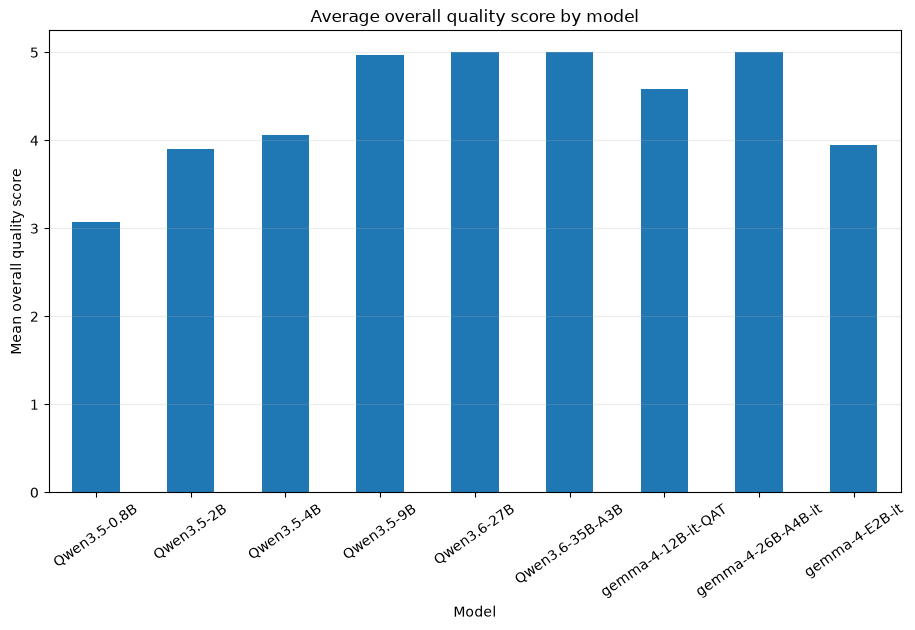

In [15]:
quality_by_model = quality.groupby("model", as_index=False).agg(observations=("overall_score", "size"), **{c: (c, "mean") for c in quality_columns})
display(quality_by_model)
save_table(quality_by_model, "05_quality_by_model.csv")
fig, ax = plt.subplots(figsize=(11, 6))
quality_by_model.set_index("model")["overall_score"].plot(kind="bar", ax=ax)
ax.set_title("Average overall quality score by model")
ax.set_xlabel("Model")
ax.set_ylabel("Mean overall quality score")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
save_figure(fig, "05_quality_by_model.png")
plt.show()

## Quality by workload

Workload-level quality differences help identify tasks for which a model is especially useful or limited.

,workload,observations,accuracy,completeness,correctness,usefulness,overall_score
0,agentic,105,3.885714,3.885714,3.971429,3.971429,3.942857
1,batch,105,4.057143,4.085714,4.057143,4.085714,4.071429
2,chat,105,4.057143,4.028571,4.057143,4.200000,4.085714
3,coding,105,3.914286,4.028571,3.914286,4.000000,3.964286
4,summarization,102,4.088235,4.205882,4.088235,4.205882,4.147059
5,world_knowledge,105,4.085714,4.085714,4.057143,4.200000,4.107143


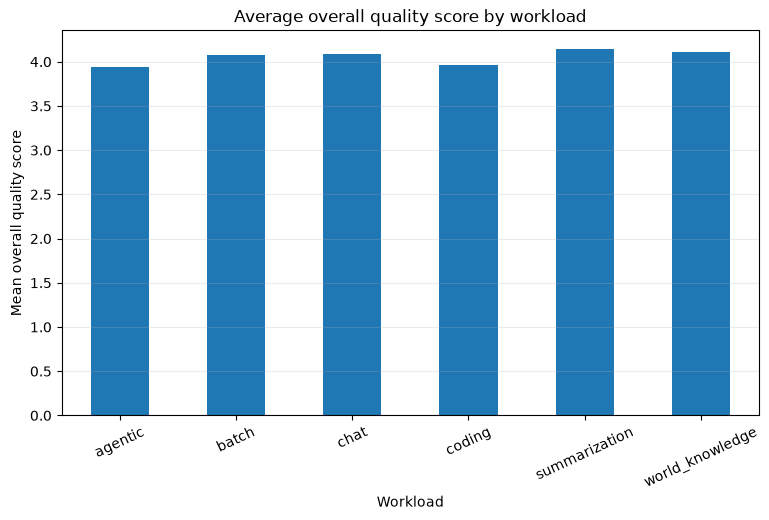

In [16]:
quality_by_workload = quality.groupby("workload", as_index=False).agg(observations=("overall_score", "size"), **{c: (c, "mean") for c in quality_columns})
display(quality_by_workload)
save_table(quality_by_workload, "05_quality_by_workload.csv")
fig, ax = plt.subplots(figsize=(9, 5))
quality_by_workload.set_index("workload")["overall_score"].plot(kind="bar", ax=ax)
ax.set_title("Average overall quality score by workload")
ax.set_xlabel("Workload")
ax.set_ylabel("Mean overall quality score")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.25)
save_figure(fig, "05_quality_by_workload.png")
plt.show()

## Decode speed versus quality

This scatter plot evaluates whether faster generation is associated with lower or higher manually assessed quality. Each point is an observed execution with both measures available.

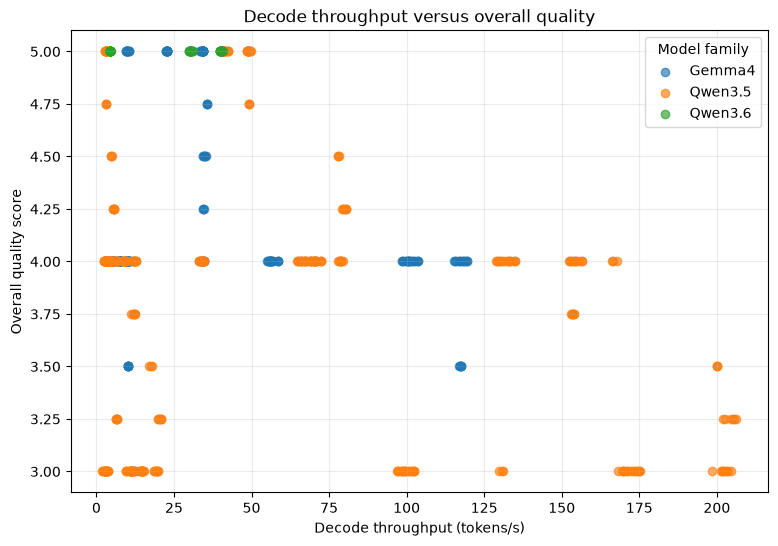

In [17]:
scatter_data = quality.dropna(subset=["decode_tps", "overall_score"])
fig, ax = plt.subplots(figsize=(9, 6))
for family, subset in scatter_data.groupby("model_family"):
    ax.scatter(subset["decode_tps"], subset["overall_score"], label=family, alpha=0.65)
ax.set_title("Decode throughput versus overall quality")
ax.set_xlabel("Decode throughput (tokens/s)")
ax.set_ylabel("Overall quality score")
ax.legend(title="Model family")
ax.grid(alpha=0.25)
save_figure(fig, "05_decode_tps_vs_quality.png")
plt.show()

## Memory versus quality

The memory-quality view makes resource trade-offs explicit. RAM and VRAM are not combined into a single physical-memory pool; the derived measure selects the resource relevant to the backend.

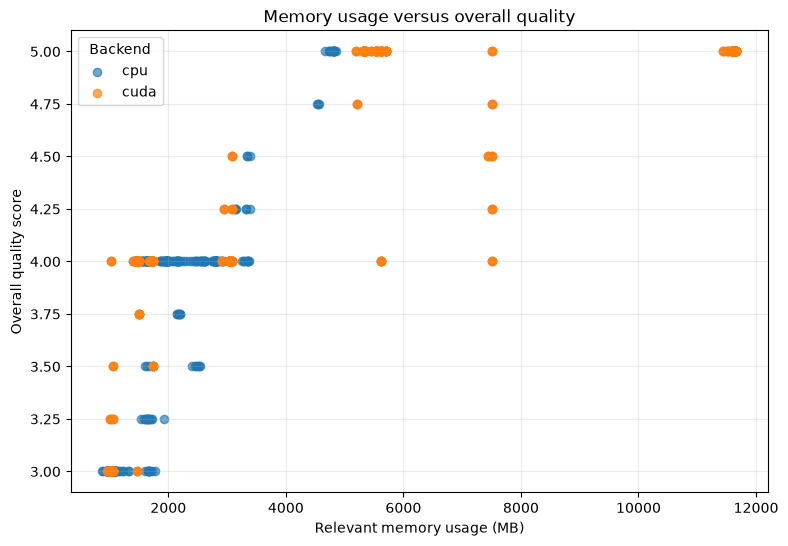

,model,backend,memory_usage_mb,decode_tps,overall_score
0,Qwen3.5-0.8B,cpu,1201.263889,11.808333,3.041667
1,Qwen3.5-0.8B,cuda,1020.666667,157.762963,3.111111
2,Qwen3.5-2B,cpu,1837.055556,9.194444,3.888889
3,Qwen3.5-2B,cuda,1463.777778,118.759259,3.916667
4,Qwen3.5-4B,cpu,2952.388889,3.931481,4.055556
5,Qwen3.5-4B,cuda,3036.666667,59.850000,4.055556
6,Qwen3.5-9B,cpu,4747.944444,3.094444,4.958333
7,Qwen3.5-9B,cuda,5311.500000,45.083333,4.979167
8,Qwen3.6-27B,cuda,11618.333333,4.488889,5.000000
9,Qwen3.6-35B-A3B,cuda,8553.333333,35.250000,5.000000


In [18]:
memory_data = quality.dropna(subset=["memory_usage_mb", "overall_score"])
fig, ax = plt.subplots(figsize=(9, 6))
for backend, subset in memory_data.groupby("backend"):
    ax.scatter(subset["memory_usage_mb"], subset["overall_score"], label=backend, alpha=0.65)
ax.set_title("Memory usage versus overall quality")
ax.set_xlabel("Relevant memory usage (MB)")
ax.set_ylabel("Overall quality score")
ax.legend(title="Backend")
ax.grid(alpha=0.25)
save_figure(fig, "05_memory_vs_quality.png")
plt.show()
tradeoff = quality.groupby(["model", "backend"], as_index=False).agg(memory_usage_mb=("memory_usage_mb", "mean"), decode_tps=("decode_tps", "mean"), overall_score=("overall_score", "mean"))
save_table(tradeoff, "05_quality_performance_tradeoff.csv")
display(tradeoff)